# Epic of Sun - Desafio 1
Training  the model.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the dataset in train, validate, and test sets
* Build the model
* Train the model
* Evaluate the model

***

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

import keras_tuner as kt

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

2026-08-10 04:26:21.991078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786346782.009200  159115 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786346782.014619  159115 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-10 04:26:22.034025: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Flags
flag_load_hyperparams = False
flag_load_model = False

In [3]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [4]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

# Specify the path to the TFRecords directory
tfrecord_path = base_path / "data" / "tfrecords"

In [5]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene01         0          0          0   
1  scene01         1          0         64   
2  scene01         2          0        128   
3  scene01         3          0        192   
4  scene01         4          0        256   

                                   x_patch_path  \
0  data/processed/scene01/images/patch_0000.npy   
1  data/processed/scene01/images/patch_0001.npy   
2  data/processed/scene01/images/patch_0002.npy   
3  data/processed/scene01/images/patch_0003.npy   
4  data/processed/scene01/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene01/masks/patch_0000.npy              1386  
1  data/processed/scene01/masks/patch_0001.npy               884  
2  data/processed/scene01/masks/patch_0002.npy                 0  
3  data/processed/scene01/masks/patch_0003.npy              1216  
4  data/processed/scene01/masks/patch_0004.npy              1787  
25000


## Selecting datasets in train, validate, and testing

In [6]:
# Function to add spectral indices to the input patches

def add_spectral_indices(X_data, eps=1e-8):
    """
    Appends spectral indices (NDVI, NDWI, EVI) as extra channels to input patches.
    
    Expected input shape: (..., H, W, 4) or (H, W, 4)
    Channels: [Blue (0), Green (1), Red (2), NIR (3)]
    """
    # Extract individual bands along the last axis
    blue  = X_data[..., 0]
    green = X_data[..., 1]
    red   = X_data[..., 2]
    nir   = X_data[..., 3]

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + eps)

    # 2. NDWI: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + eps)

    # 3. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)

    # Re-add channel dimension to calculated 2D indices
    ndvi = np.expand_dims(ndvi, axis=-1)
    ndwi = np.expand_dims(ndwi, axis=-1)
    evi  = np.expand_dims(evi, axis=-1)

    # Stack original bands with new index channels along the channel axis
    X_expanded = np.concatenate([X_data, ndvi, ndwi, evi], axis=-1)

    return X_expanded

In [7]:
# Load the best hyperparameters from the JSON file
if flag_load_hyperparams:
	json_path = base_path / "models" / "best_sugarcane_params.json"

	with open(json_path, "r") as f:
		saved_params = json.load(f)
	print("Loaded hyperparameters from JSON:")
	print(saved_params)
else:
	saved_params = {
		"init_filters": 32,
		"batch_size": 64,
		"lr": 0.0001
	}
	print("Hyperparameters not loaded from JSON. Using default values:")
	print(saved_params)

Hyperparameters not loaded from JSON. Using default values:
{'init_filters': 32, 'batch_size': 64, 'lr': 0.0001}


In [8]:
# Load the count JSON file
with open(tfrecord_path / "counts.json") as f:
    counts = json.load(f)

n_train, n_val, n_test = counts["train"], counts["val"], counts["test"]

In [9]:
# Functions to create TensorFlow datasets for training, validation, and testing

def _parse_example(example_proto):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)
    x.set_shape((128, 128, 4))
    y.set_shape((128, 128, 1))
    return x, y

def _augment(x, y):
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)
    factor = tf.random.uniform((), 0.9, 1.1)
    x = tf.clip_by_value(x * factor, 0.0, 1.0)
    return x, y

def _add_indices(x, y):
    blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)
    return x, y

def make_tfrecord_dataset(prefix, batch_size, num_patches, shuffle=True, augment=True, compute_indices=True):
    file_pattern = str(tfrecord_path / f"{prefix}_*.tfrecord")
    files = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    ds = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE
    )
	# Use this one line instead of the next one to avoid the error "ValueError: 
	# num_parallel_calls must be a tf.int32 scalar tensor or None."
    ds = ds.map(_parse_example, num_parallel_calls=tf.data.AUTOTUNE)
	# Use this line to avoid overheading the CPU with too many parallel calls, 
	# which can lead to the error "ValueError: num_parallel_calls must be a 
	# tf.int32 scalar tensor or None."
    #ds = ds.map(_parse_example, num_parallel_calls=2)  # instead of AUTOTUNE

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    if compute_indices:
        ds = ds.map(_add_indices, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    num_batches = math.ceil(num_patches / batch_size)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [10]:
# Create TensorFlow datasets for training, validation, and testing
train_ds = make_tfrecord_dataset("train", saved_params["batch_size"], n_train, shuffle=True, augment=True)
val_ds   = make_tfrecord_dataset("val",   saved_params["batch_size"], n_val,   shuffle=False, augment=True)
test_ds  = make_tfrecord_dataset("test",  saved_params["batch_size"], n_test,  shuffle=False, augment=False)

I0000 00:00:1786346803.109168  159115 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9326 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
# Show the number of batches in training, validation, and testing sets
# Taken form the counts.json file, which is generated during the TFRecord creation process
print("Training batches:", n_train)
print("Validation batches:", n_val)
print("Testing batches:", n_test)

Training batches: 15000
Validation batches: 5000
Testing batches: 5000


In [12]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = next(iter(train_ds))

print("Training batch shape:", X_batch.shape)
print("Training label shape:", y_batch.shape)
print("Training batch data type:", X_batch.dtype)
print("Training label data type:", y_batch.dtype)

2026-08-10 04:26:59.248252: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-08-10 04:27:09.242748: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 1094 of 2000
2026-08-10 04:27:20.625791: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Training batch shape: (64, 128, 128, 7)
Training label shape: (64, 128, 128, 1)
Training batch data type: <dtype: 'float32'>
Training label data type: <dtype: 'float32'>


## Build the Model

In [13]:
# Loss functions

# Binary cross-entropy treats every pixel independently and doesn't "know" about overlap; 
# Dice loss directly optimizes for segmentation overlap, which is exactly what IoU measures, 
# and it tends to push recall up for the minority-in-that-image foreground class without 
# hurting precision much.

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def combined_loss(alpha=0.5):
    """
    alpha: weight on BCE component. (1-alpha) weight on Dice.
    alpha=1.0 -> pure BCE (your original, precision-favoring setup)
    alpha=0.0 -> pure Dice (recall/overlap-favoring, likely what you just ran)
    alpha=0.5 -> balanced mix
    """
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        smooth = 1e-6
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = 1 - (2. * intersection + smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
        )

        return alpha * bce + (1 - alpha) * dice
    return loss_fn

In [14]:
"""
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x
"""

'\n# Convolution block\n# Each block performs Conv -> ReLU -> Conv -> ReLU\n\ndef conv_block(inputs, filters):\n\n    x = layers.Conv2D(\n        filters,\n        3,\n        padding="same",\n        activation="relu"\n    )(inputs)\n\n    x = layers.Conv2D(\n        filters,\n        3,\n        padding="same",\n        activation="relu"\n    )(x)\n\n    return x\n'

In [15]:
# Convolution block
# Each block performs 
# Conv -> BatchNormalization -> ReLU -> Conv -> BatchNormalization -> ReLU

def conv_block(inputs, filters, dropout=0.0):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x

In [16]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [17]:
# Decoder block
# Each block performs:
#  upsamples
#  concatenates the skip connection
#  performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [18]:
"""
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)  # 32
    s2, p2 = encoder_block(p1, init_filters * 2)  # 64
    s3, p3 = encoder_block(p2, init_filters * 4)  # 128
    s4, p4 = encoder_block(p3, init_filters * 8)  # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16)        # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)  # 256
    d2 = decoder_block(d1, s3, init_filters * 4)  # 128
    d3 = decoder_block(d2, s2, init_filters * 2)  # 64
    d4 = decoder_block(d3, s1, init_filters)      # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
			learning_rate=lr, 
			weight_decay=1e-4
		),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )
    return model
"""

'\n# Function to build the network, compile it, use tunned hyperparameters, and return the model\n\ndef build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):\n    inputs = layers.Input(input_shape)\n    \n    # Encoder\n    s1, p1 = encoder_block(inputs, init_filters)  # 32\n    s2, p2 = encoder_block(p1, init_filters * 2)  # 64\n    s3, p3 = encoder_block(p2, init_filters * 4)  # 128\n    s4, p4 = encoder_block(p3, init_filters * 8)  # 256\n    \n    # Bottleneck\n    b1 = conv_block(p4, init_filters * 16)        # 512\n    \n    # Decoder\n    d1 = decoder_block(b1, s4, init_filters * 8)  # 256\n    d2 = decoder_block(d1, s3, init_filters * 4)  # 128\n    d3 = decoder_block(d2, s2, init_filters * 2)  # 64\n    d4 = decoder_block(d3, s1, init_filters)      # 32\n    \n    # Output\n    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)\n    model = Model(inputs, outputs)\n    \n    # Unified comilation with the original metrics\n    model.compile(\n        optimizer=tf.k

In [19]:
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)        # 32
    s2, p2 = encoder_block(p1, init_filters * 2)        # 64
    s3, p3 = encoder_block(p2, init_filters * 4)        # 128
    s4, p4 = encoder_block(p3, init_filters * 8)        # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16, dropout=0.3) # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)        # 256
    d2 = decoder_block(d1, s3, init_filters * 4)        # 128
    d3 = decoder_block(d2, s2, init_filters * 2)        # 64
    d4 = decoder_block(d3, s1, init_filters)            # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        #loss=bce_dice_loss,
		loss=combined_loss(alpha=0.7),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
        ]
    )
    return model

In [20]:
# Create the model with the best hyperparameters
model = build_unet(
    init_filters=saved_params["init_filters"], 
    lr=saved_params["lr"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,016 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 7,770,081 (29.64 MB)

 Trainable params: 7,764,193 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [21]:
# You can just load the model if already trained and not run again

history_dict = None  # Initialize history_dict to None

if flag_load_model:
	model_path = base_path / "models" / "unet_sugarcane.keras"
	history_path = base_path / "models" / "training_history.json"

	if model_path.exists():
		try:
			# Pass str(model_path) to ensure compatibility
			model = load_model(str(model_path), compile=False)
			print("Successfully loaded saved model.")
		except Exception as e:
			print(f"File exists, but load_model failed with error:\n{e}")
	else:
		print("File does not exist at the specified path. Check your working directory or base_path.")
	
	if history_path.exists():
		try:
			with open(str(history_path), 'r') as f:
				history_dict = json.load(f)
			print("Successfully loaded saved training history.")
		except Exception as e:
			print(f"File exists, but loading training history failed with error:\n{e}")
	else:
		print("Training history file does not exist at the specified path. Check your working directory or base_path.")
else:
	print("Model loading skipped. Training a new model from scratch using given hyperparameter values.")

Model loading skipped. Training a new model from scratch using given hyperparameter values.


## Train the model

In [22]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "unet_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [24]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1
)

In [25]:
# Train the model
if not flag_load_model:
	print("Training a new model.")
	history = model.fit(
		train_ds,
		validation_data=val_ds,
		epochs=50,
		callbacks=[checkpoint, early_stop, reduce_lr],
		verbose=1
	)
	history_dict = history.history
	print("Training completed.")
else:
	print("Model loaded, skipping training.")

Training a new model.
Epoch 1/50


2026-08-10 04:27:46.308420: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 847 of 2000
2026-08-10 04:27:58.700208: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
I0000 00:00:1786346879.314289  166597 service.cc:148] XLA service 0x71e7240137e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786346879.457196  166597 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-10 04:28:00.460905: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786346882.759904  166597 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1786346930.242297  166597 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.

235/235 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - binary_accuracy: 0.7582 - loss: 0.4582 - precision: 0.6760 - recall: 0.7688 - val_binary_accuracy: 0.5377 - val_loss: 0.7370 - val_precision: 0.4802 - val_recall: 0.3333 - learning_rate: 1.0000e-04
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 206ms/step - binary_accuracy: 0.8273 - loss: 0.3695 - precision: 0.7939 - recall: 0.7719 - val_binary_accuracy: 0.5670 - val_loss: 0.8424 - val_precision: 0.5106 - val_recall: 0.9063 - learning_rate: 1.0000e-04
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 51s 218ms/step - binary_accuracy: 0.8437 - loss: 0.3437 - precision: 0.8092 - recall: 0.8011 - val_binary_accuracy: 0.5520 - val_loss: 1.1268 - val_precision: 0.8913 - val_recall: 0.0049 - learning_rate: 1.0000e-04
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 54s 231ms/step - binary_accuracy: 0.8560 - loss: 0.3244 - precision: 0.8289 - recall: 0.8100 - val_binary_accuracy: 0.7342 - val_loss: 0.4641 - val_precision: 0.7465 - val_recall: 0.6195 - learning_rate: 1.00

In [26]:
# Save the model and its history for future use.
# The model is saved in the Keras format (.keras) which includes both architecture and weights.

if not flag_load_model:
	# Save the model.
	model_path = base_path / "models" / "unet_sugarcane.keras"
	model.save(str(model_path))
	print(f"Model saved to '{model_path}'")

	# Save the training history as a JSON file for future reference.
	history_path = base_path / "models" / "training_history.json"
	with open(str(history_path), 'w') as f:
		json.dump(history_dict, f)
	print(f"Training history saved to '{history_path}'")
else:
	print("Skipping saving model and history.")

Model saved to '/home/fdesmello/Git/spacesugar/models/unet_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar/models/training_history.json'


## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/loss_accuracy.png'


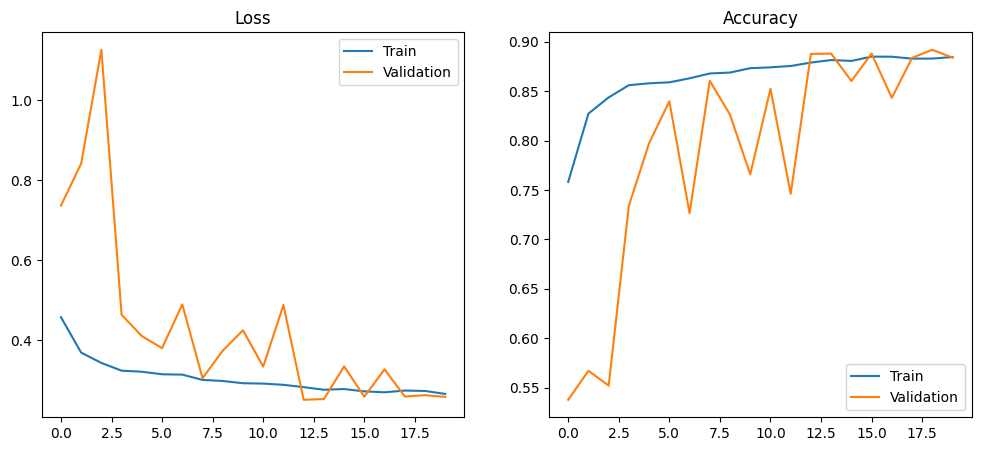

In [27]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()

In [28]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb

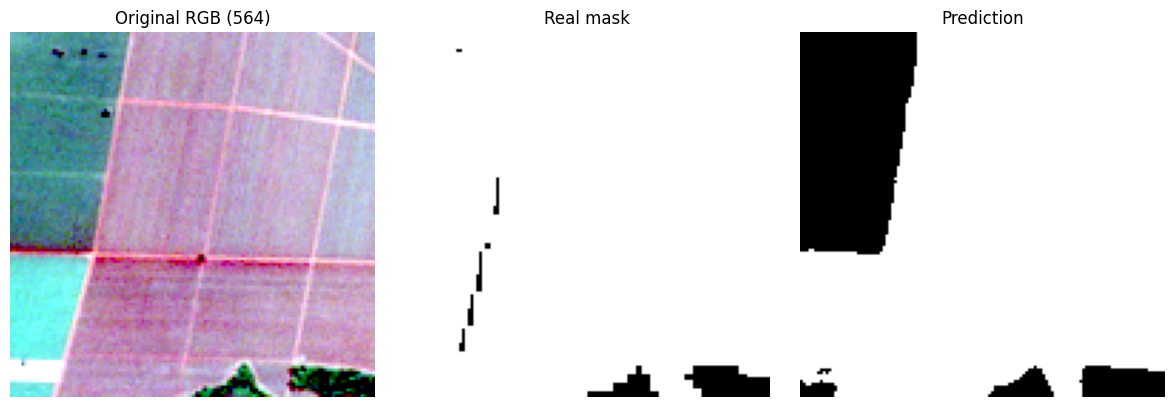

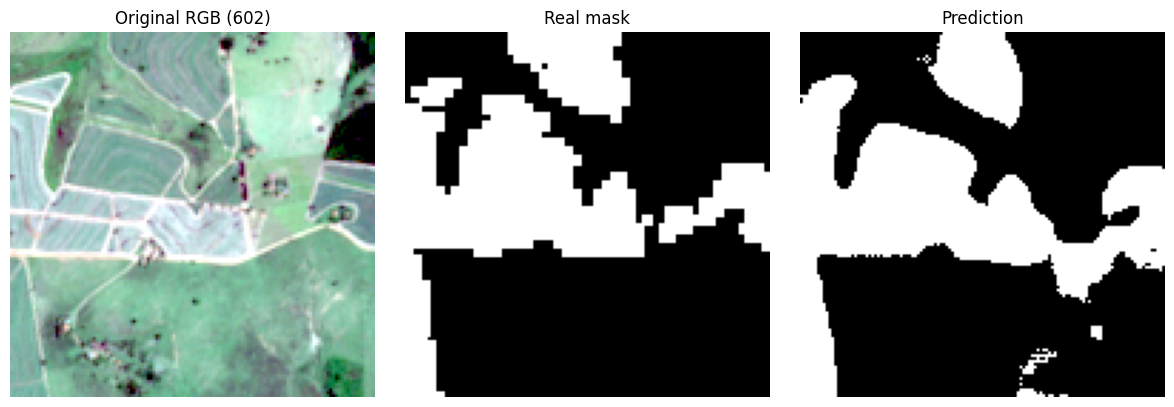

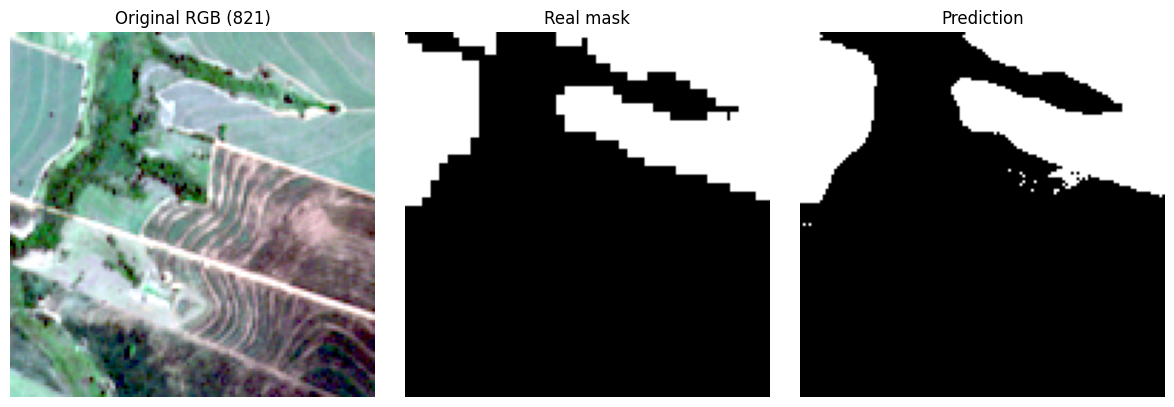

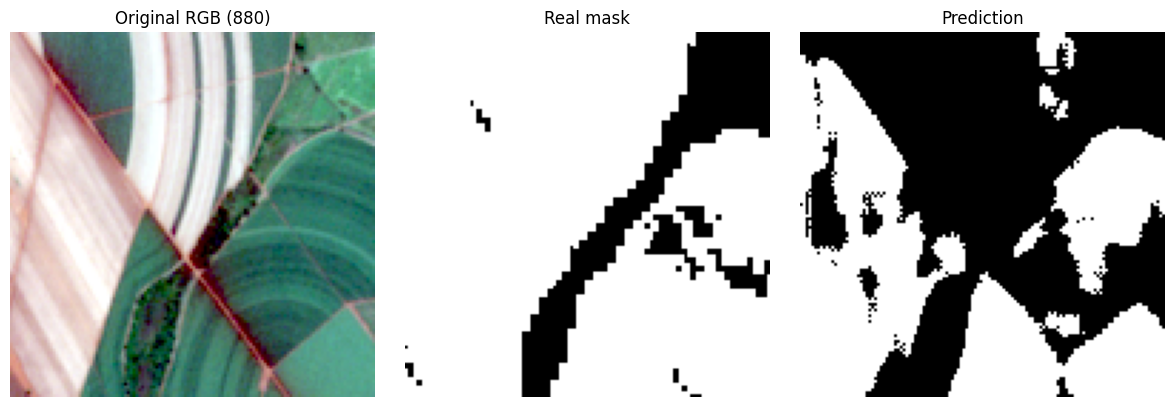

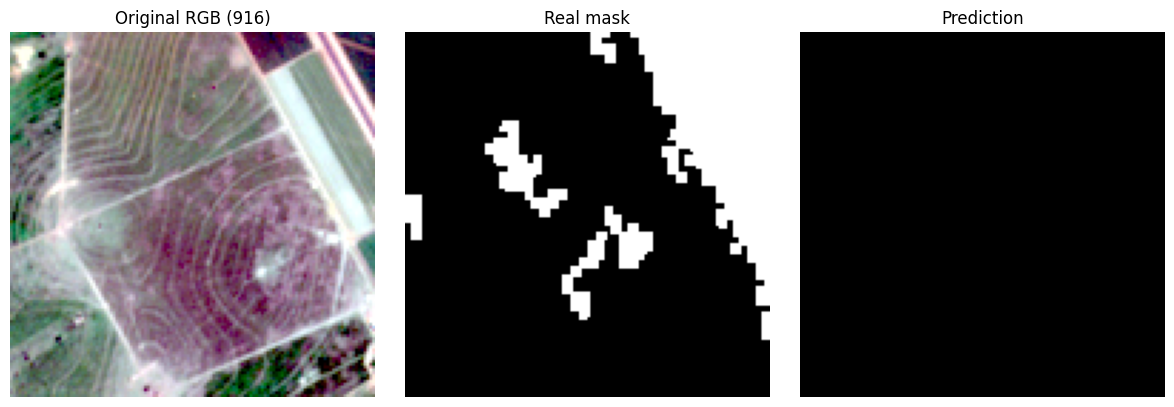

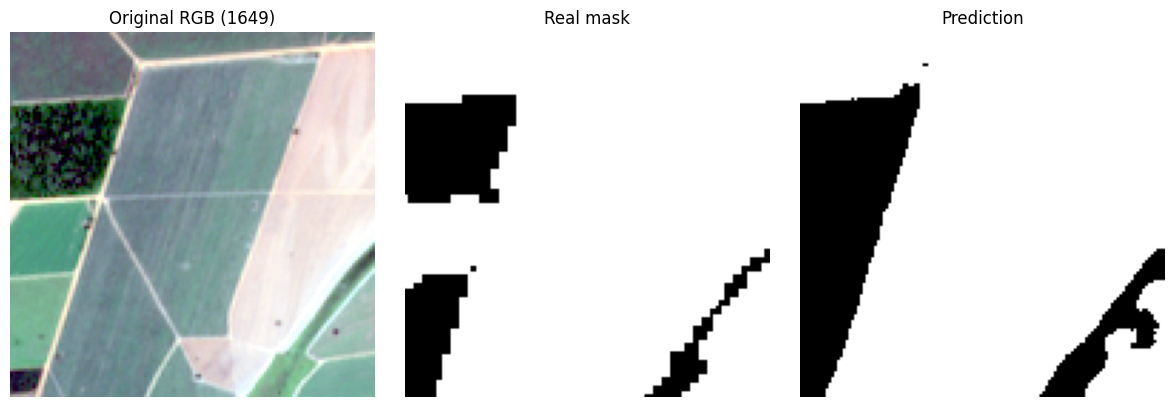

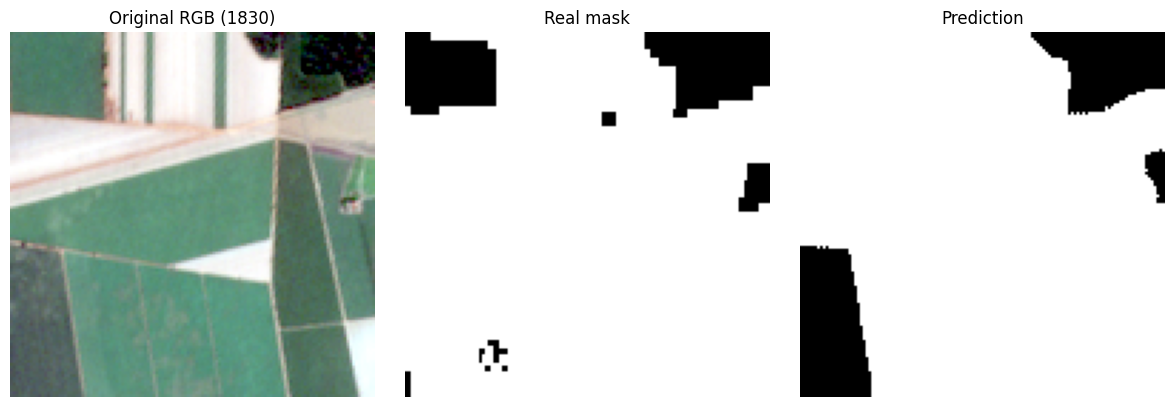

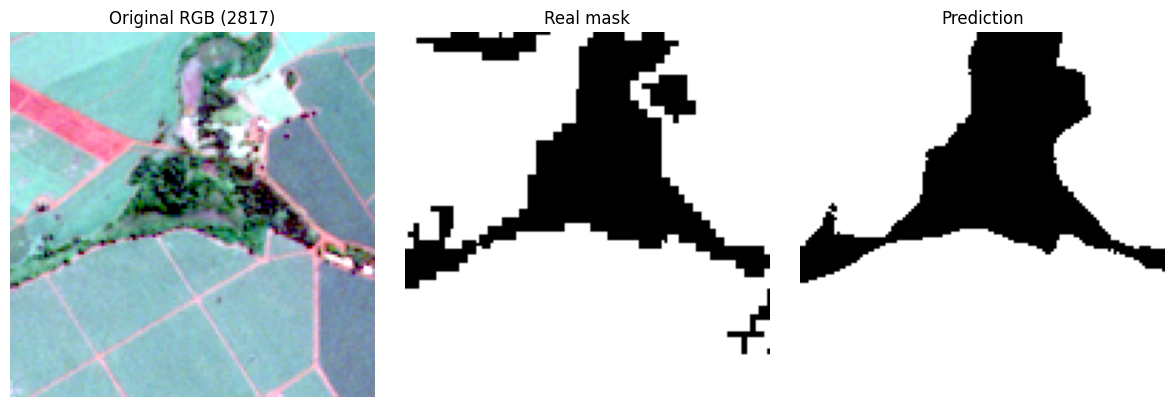

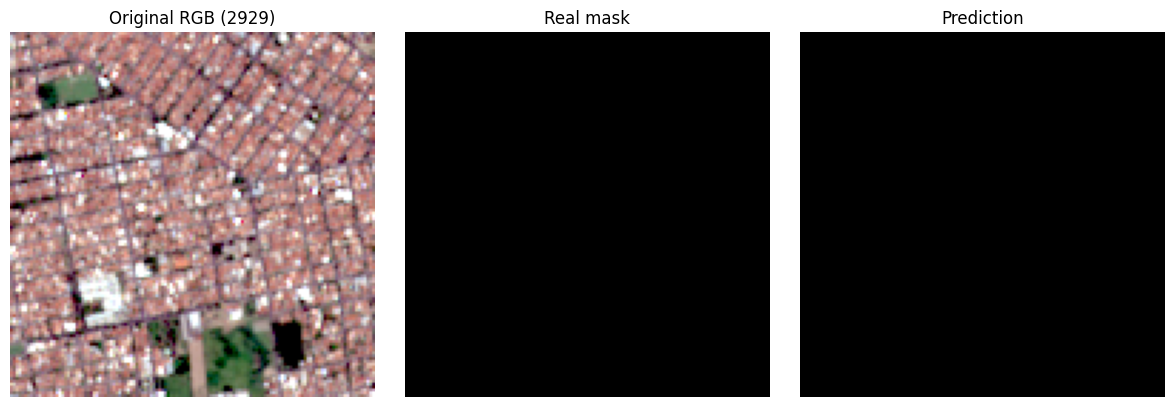

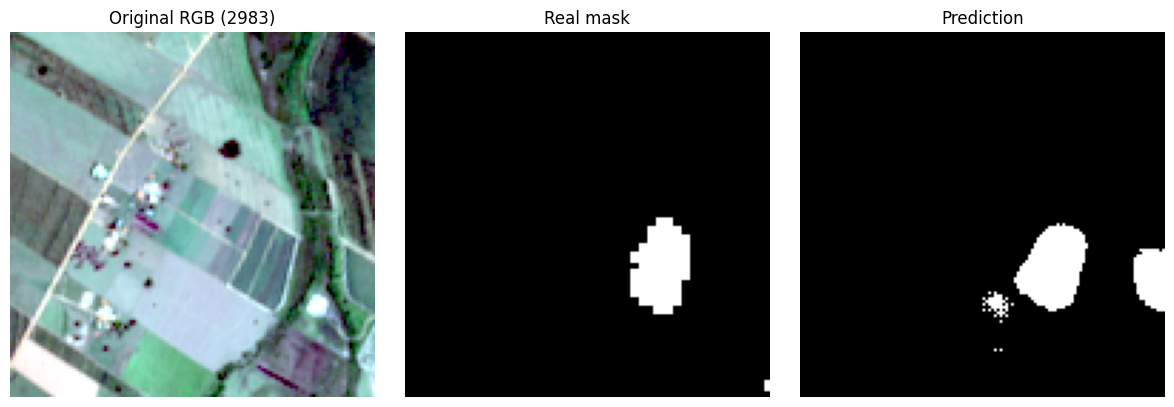

2026-08-10 04:50:22.347478: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [29]:
# Make all the predictions on the test set and visualize 4 random results

max_plots = 10
j = 0

all_predictions = []
all_targets = []

plot_indices = set(random.sample(range(n_test), k=max_plots))
global_index = 0

for X_batch, y_batch in test_ds:
    X_batch_np = X_batch.numpy()
    y_batch_np = y_batch.numpy()

    pred_batch = model.predict(X_batch, verbose=0)

    all_predictions.extend(pred_batch)
    all_targets.extend(y_batch_np)

    for k in range(X_batch_np.shape[0]):
        if global_index in plot_indices:
            pred = pred_batch[k]
            binary_pred = pred > 0.5

            fig, ax = plt.subplots(1, 3, figsize=(12, 4))

            rgb = np.clip(X_batch_np[k][:, :, [2, 1, 0]], 0, 1).copy()
            rgb = stretch_rgb(rgb)

            ax[0].imshow(rgb)
            ax[0].set_title(f"Original RGB ({global_index})")
            ax[0].axis("off")

            ax[1].imshow(y_batch_np[k].squeeze(), cmap="gray")
            ax[1].set_title("Real mask")
            ax[1].axis("off")

            ax[2].imshow(binary_pred.squeeze(), cmap="gray")
            ax[2].set_title("Prediction")
            ax[2].axis("off")

            file_path = base_path / "figures" / f"unet_sugarcane_results_{j}.png"
            plt.tight_layout()
            plt.savefig(file_path, dpi=300, bbox_inches="tight")
            plt.show()

            j += 1

        global_index += 1

In [36]:
# Metrics Calculation

# 1. Collect predictions into a matching NumPy array
y_pred_all = np.array(all_predictions)
y_true_all = np.array(all_targets)

# 2. Convert probabilities to binary masks
y_pred_bin = (y_pred_all > 0.5).astype(np.uint8)
y_true_bin = y_true_all.astype(np.uint8)

# 3. Flatten the entire sets to 1D arrays
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3.5. Calculate float probailities
y_true_float = y_true_all.ravel()
y_pred_float = y_pred_all.ravel()

# 4. Calculate global metrics
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
roc_auc = roc_auc_score(y_true_flat, y_pred_flat)

print(f"Metrics for the test dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 5. Intersection over Union (IoU) for the sugarcane class
# Instantiate the metric object
# target_class_ids=[1] isolates the sugarcane class, ignoring background pixels
iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)

# Update the metric state with true masks and predicted probabilities
iou_metric.update_state(y_true_flat, y_pred_flat)

# Extract and print the final result
final_iou = iou_metric.result().numpy()
print(f"IoU: {final_iou:.4f}")

# 6. Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("\nConfusion Matrix:")
print(cm)

Metrics for the test dataset:
Precision: 0.8183
Recall: 0.8077
F1-Score: 0.8129
ROC AUC Score: 0.8451
IoU: 0.6848

Confusion Matrix:
[[43694818  5814690]
 [ 6232342 26178150]]


In [35]:
# Save data as json file for future reference
metrics_data = {
	"precision": float(p),
	"recall": float(r),
	"f1_score": float(f1),
	"roc_auc": float(roc_auc),
	"iou": float(final_iou),
	"confusion_matrix": cm.tolist()
}

metrics_path = base_path / "models" / "metrics_data.json"
with open(str(metrics_path), "w") as f:
	json.dump(metrics_data, f)
print(f"Metrics data saved to '{metrics_path}'")

Metrics data saved to '/home/fdesmello/Git/spacesugar/models/metrics_data.json'


In [31]:
# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true_flat, y_pred_flat, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88  49509508
           1       0.82      0.81      0.81  32410492

    accuracy                           0.85  81920000
   macro avg       0.85      0.85      0.85  81920000
weighted avg       0.85      0.85      0.85  81920000



In [32]:
# 8. Evaluate different thresholds

y_true_flat_threshold = np.concatenate([t.flatten() for t in all_targets])
y_pred_flat_threshold = np.concatenate([p.flatten() for p in all_predictions])

print("\nEvaluating different thresholds:")
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    binary = y_pred_flat_threshold > thresh
    p = precision_score(y_true_flat_threshold, binary)
    r = recall_score(y_true_flat_threshold, binary)
    f1 = f1_score(y_true_flat_threshold, binary)
    print(f"thresh={thresh:.1f}  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}")


Evaluating different thresholds:
thresh=0.3  precision=0.785  recall=0.855  f1=0.818
thresh=0.4  precision=0.803  recall=0.831  f1=0.817
thresh=0.5  precision=0.818  recall=0.808  f1=0.813
thresh=0.6  precision=0.833  recall=0.780  f1=0.805
thresh=0.7  precision=0.848  recall=0.741  f1=0.791
thresh=0.8  precision=0.868  recall=0.672  f1=0.757



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_probabilities.png'


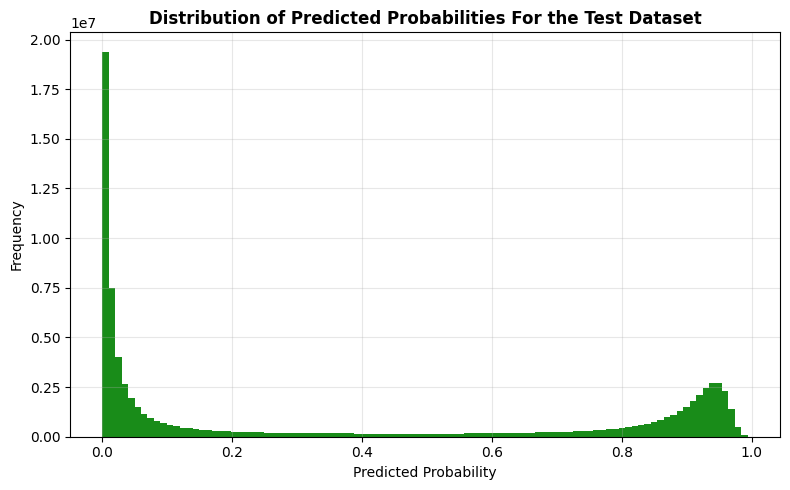

In [45]:
# Probability distribution

fig = plt.figure(figsize=(8, 5))
#plt.suptitle('Distribution of Predicted Probabilities For the Test Dataset', fontsize=14, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Prediction Probability Distribution
ax1 = plt.subplot(1, 1, 1)
ax1.hist(y_pred_float, bins=100, alpha=0.9, label='Sugarcane probabilities', color='green')
ax1.set_xlabel('Predicted Probability')
ax1.set_ylabel('Frequency')
#ax1.set_yscale('log')
ax1.set_title('Distribution of Predicted Probabilities For the Test Dataset', fontsize=12, fontweight='bold')
#ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_probabilities.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()

/tmp/ipykernel_159115/2296661133.py:69: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_159115/2296661133.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(file_path, dpi=300, bbox_inches='tight')



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_results.png'


/home/fdesmello/miniconda3/envs/sugarcane/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


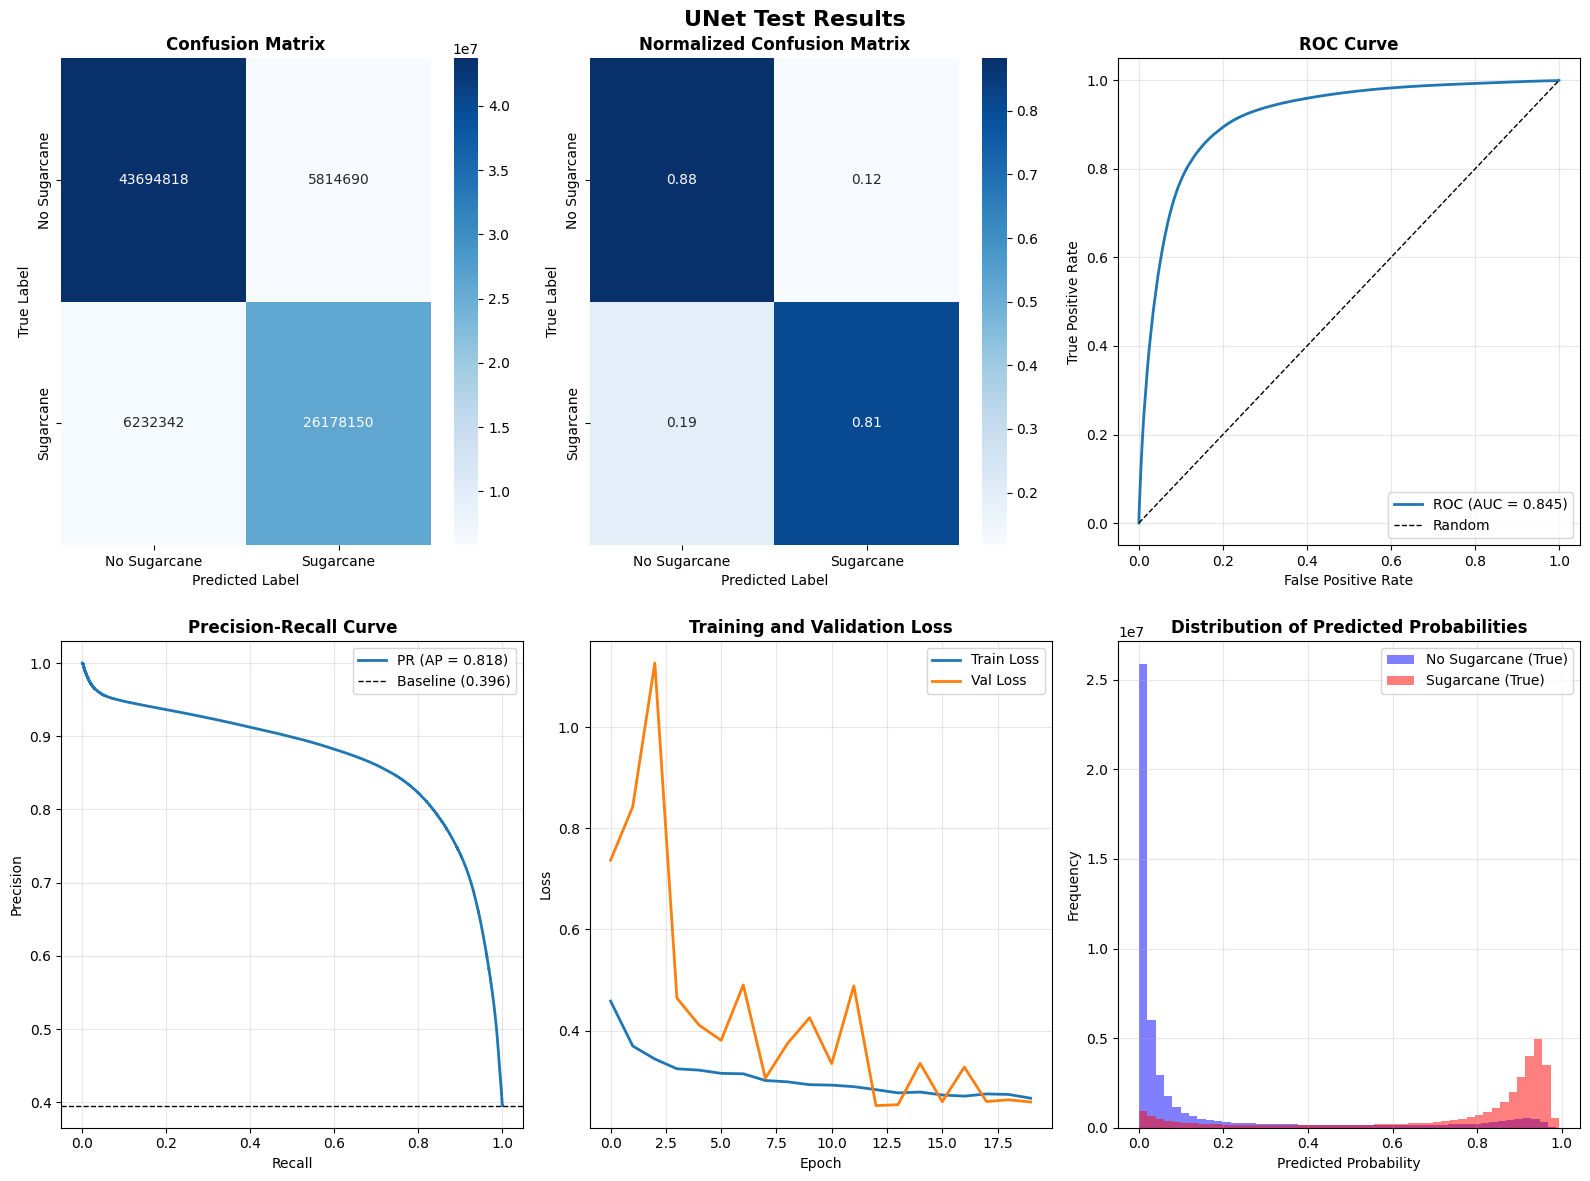

In [42]:
# Visualizations

fig = plt.figure(figsize=(16, 12))
plt.suptitle('UNet Test Results', fontsize=16, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
cm_norm = pd.DataFrame(cm).apply(lambda x: x/sum(x), axis = 1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve
if len(np.unique(y_true_float)) > 1:
    ax3 = plt.subplot(2, 3, 3)
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_float)
    ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
if len(np.unique(y_true_float)) > 1:
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_float)
    ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
    ax4.axhline(y=y_true_flat.mean(), color='k', linestyle='--', linewidth=1, 
                label=f'Baseline ({y_true_flat.mean():.3f})')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# 5. Training and Validation Loss
ax5 = plt.subplot(2, 3, 5)
ax5.plot(history_dict["loss"], label='Train Loss', linewidth=2)
ax5.plot(history_dict["val_loss"], label='Val Loss', linewidth=2)
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Loss')
ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3) 

# 6. Prediction Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_float[y_true_flat == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_float[y_true_flat == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
#ax6.set_yscale('log')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_results.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()